# Optimization

#### Imports

In [2]:
%reload_ext autoreload
%autoreload 2

In [3]:
import sys
import os

# Add the parent directory (or another appropriate path) to sys.path so Python can find Exclusion_functions
notebook_dir = os.path.dirname(os.path.abspath('04_Optimization.ipynb'))
parent_dir = os.path.abspath(os.path.join(notebook_dir, '..', '..', '..'))
function_dir = os.path.abspath(os.path.join(parent_dir, 'Function_Files'))
if function_dir not in sys.path:
    sys.path.append(function_dir)

In [4]:
import pandas as pd
import polars as pl
import Exclusion_functions as ef
import Optimization_functions as of
import Final_report_functions as frf
import datetime

In [5]:
CATEGORY = "Cutlery"
today = datetime.datetime.now().strftime('%m.%d.%Y')
ip_path = f"{parent_dir}\\Data\\"
ip_path_cat = f"{parent_dir}\\Data\\{CATEGORY}"
#OP_PATH = "C:\\Users\\ZWayne\\OneDrive - Advent International\\Advent Labs - Documents\\02. Portfolio Companies\\Imperial Dade\\Category Mgmt Project\\Data\\Output\\"

In [58]:
#im_final = pd.read_excel(f"{OP_PATH}{CATEGORY}_Subs_df_{today}_post_feedback.csv", index=False)
df = pd.read_excel(f"{ip_path_cat}\\Cutlery Sales Data for Cost Analysis L6M Feb - July 25.xlsx")
df = df.iloc[:-4,:]

rebates = pd.read_excel(f"{ip_path}\\Rebates.xlsx")
rebates = rebates.drop_duplicates(subset=['VGN'])

In [76]:
df_rebate = df.merge(
    rebates[['VGN', 'Imperial Rebate % 2024']],
    on='VGN',
    how='left'
)
df_rebate.loc[:, 'Imperial Rebate % 2024'] = df_rebate['Imperial Rebate % 2024'].fillna(0)
df_rebate['Net Cost (after rebate)'] = df_rebate['Net Cost'] * (1 - df_rebate['Imperial Rebate % 2024'])

In [77]:
df_rebate['Case Pack'] = df_rebate['Case Pack'].astype(str).str.replace(r'[^0-9.]', '', regex=True)
df_rebate = df_rebate[df_rebate['Case Pack'].str.strip() != '']
df_rebate['Case Pack'] = pd.to_numeric(df_rebate['Case Pack'], errors='coerce')

## fix so rebate doesn't effect POD

In [ ]:
df_grouped = df_rebate.groupby(['Item', 'POD']).agg({
    'Qty': 'sum',
    'Net Cost (after rebate)': 'sum',
    'Case Pack': 'mean'
}).reset_index().rename(columns={'Case Pack': 'Avg Case Pack'})

df_grouped.loc[:, 'Acq PO Cost (after rebate)'] = df_grouped['Net Cost (after rebate)'] / df_grouped['Qty']

In [ ]:
import numpy as np

# Get unique items and their indices
unique_items = df_grouped[(df_grouped['Avg Case Pack'] > 0)]['Item'].unique()
n = len(unique_items)

# Create a mapping from item to its Acq PO Cost (after rebate) where POD == 'N'
item_Non_POD_cost_dict = df_grouped[df_grouped['POD'] == 'N'].set_index('Item')['Acq PO Cost (after rebate)'].to_dict()
item_Non_POD_qty_dict = df_grouped[df_grouped['POD'] == 'N'].set_index('Item')['Qty'].to_dict()
item_case_pack_dict = df_grouped.groupby('Item')['Avg Case Pack'].mean().to_dict()
item_POD_cost_dict = df_grouped[df_grouped['POD'] == 'Y'].set_index('Item')['Acq PO Cost (after rebate)'].to_dict()
item_POD_qty_dict = df_grouped[df_grouped['POD'] == 'Y'].set_index('Item')['Qty'].to_dict()

# Initialize the matrix
cost_diff_matrix = np.zeros((n, n))

# Fill the matrix
for i, item_i in enumerate(unique_items):
    for j, item_j in enumerate(unique_items):
        POD_cost_i = item_POD_cost_dict.get(item_i, np.nan)
        POD_qty_i = item_POD_qty_dict.get(item_i, np.nan)

        Non_POD_cost_i = item_Non_POD_cost_dict.get(item_i, np.nan)
        Non_POD_qty_i = item_Non_POD_qty_dict.get(item_i, np.nan)

        case_pack_i = item_case_pack_dict.get(item_i, np.nan)
        case_pack_ratio_i = 1000/case_pack_i

        adj_Non_POD_cost_i = Non_POD_cost_i*case_pack_ratio_i
        adj_POD_cost_i = POD_cost_i*case_pack_ratio_i
        adj_Non_POD_qty_i = Non_POD_qty_i*(1/case_pack_ratio_i)
        adj_POD_qty_i = POD_qty_i*(1/case_pack_ratio_i)


        cost_j = item_Non_POD_cost_dict.get(item_j, np.nan)
        case_pack_j = item_case_pack_dict.get(item_j, np.nan)
        case_pack_ratio_j = 1000/case_pack_j
        adj_cost_j = cost_j*case_pack_ratio_j

        Non_POD_savings = (adj_Non_POD_cost_i - adj_cost_j)*adj_Non_POD_qty_i
        POD_savings = (adj_POD_cost_i - adj_cost_j)*adj_POD_qty_i

        if np.isnan(Non_POD_savings):
            Non_POD_savings = 0
        if np.isnan(POD_savings):
            POD_savings = 0

        cost_diff_matrix[i, j] = Non_POD_savings + POD_savings

cost_diff_df = pd.DataFrame(cost_diff_matrix, index=unique_items, columns=unique_items)


In [135]:
item = '.SP-CS-3'
def matrix_lookup(cost_diff_df, item):
    # count how many in column is positive vs negative
    positive_count = cost_diff_df[item] > 0
    negative_count = cost_diff_df[item] < 0
    positive_count = positive_count.sum()
    negative_count = negative_count.sum()
    print(f"Positive count: {positive_count}, Negative count: {negative_count}")
    return positive_count, negative_count

matrix_lookup(cost_diff_df, item)

Positive count: 2930, Negative count: 836


(2930, 836)

#### Get Exclusions

In [5]:
ID_vendors = pd.read_csv(f"{OP_PATH}top_non_imperial_dade_vgn.csv")
im_final['vgn_name'] = im_final.apply(lambda x: ID_vendors[ID_vendors['Entity--Item'] == x['Entity--Item']]['top_non_imperial_dade_vgn'].values[0] if x['vgn_name'] == 'Imperial Dade' and not ID_vendors[ID_vendors['Entity--Item'] == x['Entity--Item']]['top_non_imperial_dade_vgn'].empty else x['vgn_name'], axis=1)

In [27]:
im_final, true_l3m_final = ef.get_transactions_data(im_final, f"{ip_path}Country of Origin - Active Only.csv", exclude_canada_rows=True)

true_l3m_g = true_l3m_final.join(
    pl.from_pandas(im_final).select(["Entity--Item", "Matches", "vgn_name"]),
    on="Entity--Item",
    how="left"
)
# Group by Entity--Item and customer
true_l3m_grouped = true_l3m_g.group_by(["Entity--Item", "customer"]).agg([
    pl.col("L3M_sales").sum().alias("L3M_Sales"),
    pl.col("L3M_net_cost").sum().alias("L3M_Cogs"),
    pl.col("L3M_adj_vol").sum().alias("L3M_adj_vol"),
    pl.col("Matches").first().alias("Matches")
])

In [7]:
vendor_exclusions = pd.read_excel(f"{ip_path}Customer and Vendor Exclusions.xlsx", sheet_name="VGN Table list", skiprows=2)
vendor_exclusions = set(vendor_exclusions[vendor_exclusions['Nonaddressable'] == 'X']['VGN'].tolist())
vendor_exclusions = vendor_exclusions.union(['Direct Link','Carryout Bags, Inc.'])
vendor_exclusions = im_final[im_final['vgn_name'].isin(vendor_exclusions)]['Entity--Item'].unique().tolist()
print(f"Found {len(vendor_exclusions)} unqiue SKUS bought by excluded vendors")

Found 711 unqiue SKUS bought by excluded vendors


In [8]:
redi = ef.get_skus_to_redi(true_l3m_final, customer_data_path="C:\\Users\\zwayne\\OneDrive - Advent International\\Advent Labs - Documents\\02. Portfolio Companies\\Imperial Dade\\Client_segmentation\\Files\\Fornax.dbo.vCustomers Entity 1.csv", account_code_col='account_code', 
                       customer_no_col='Customer_No', customer_class_col='Customer_Class')
redi_skus = redi['Entity--Item'].unique().to_list()

Found 1358 unique SKUs serving redi customers


In [9]:
customer_exclusions = pd.read_excel(f"{ip_path}Customer and Vendor Exclusions.xlsx", sheet_name="Customer Table list", skiprows=2)
customer_exclusions = set(customer_exclusions[customer_exclusions['Nonaddressable'] == 'X']['Customer Name'].tolist())
get_skus_to_excl_cust = ef.get_skus_to_excl_cust(true_l3m_final, customer_exclusions)
customer_exclusions_skus = get_skus_to_excl_cust['Entity--Item'].unique().to_list()

Found 1211 unique SKUs bought by excluded customers


In [10]:
must_keep_ids = list(set(vendor_exclusions + redi_skus + customer_exclusions_skus)); len(must_keep_ids)

1951

#### Prepare Optimization

In [37]:
#must_keep_ids = [] # Example must-keep items
A, v, sl, cl, S, must_keep_indices, skus_order, suppliers_order, item_to_idx_map, supplier_to_idx_map, el = of.prepare_optimization_inputs(im_final, must_keep_ids, rebates =None)

# These can now be used in your PuLP script
num_skus_pulp = len(skus_order)
num_suppliers_pulp = len(suppliers_order)
SKUS_pulp = list(range(num_skus_pulp))
SUPPLIERS_pulp = list(range(num_suppliers_pulp))

Supplier matrix S shape: (3031, 170)


#### Loop through optimization

In [32]:
results = of.solve_supplier_optimization_looped(SKUS_pulp, SUPPLIERS_pulp, v, A, S, 2, sl, cl,  must_keep_sku_ids = must_keep_indices, entity_list= el)

--- Initializing Looped Optimization Problem ---
Starting optimization loop. Initial max suppliers: 170

--- Solving for Max Suppliers <= 170 ---
--- Initializing Optimization Problem ---
SKUs (count: 3031): ['0', '1', '2']...
Suppliers (count: 170): ['0', '1', '2']...
Max volume factor (beta): 2
Big M for constraints: 80088415.0
Objective function set to maximize_gm_dollars.
Adding Volume Redistribution Limit constraints...
    Note: SKU 576 has ~0 original volume. Max redistributed volume capped at 528.64.
Adding Supplier Activation constraints (per-SKU linking)...
Adding SKU Give-or-Receive constraints...
Adding Entity constraint...

--- Solving the Optimization Problem ---

--- Optimization Results ---
Status: Optimal
Total number of active suppliers: 170

--- Solving for Max Suppliers <= 166 ---
--- Initializing Optimization Problem ---
SKUs (count: 3031): ['0', '1', '2']...
Suppliers (count: 170): ['0', '1', '2']...
Max volume factor (beta): 2
Big M for constraints: 80088415.0
Ob

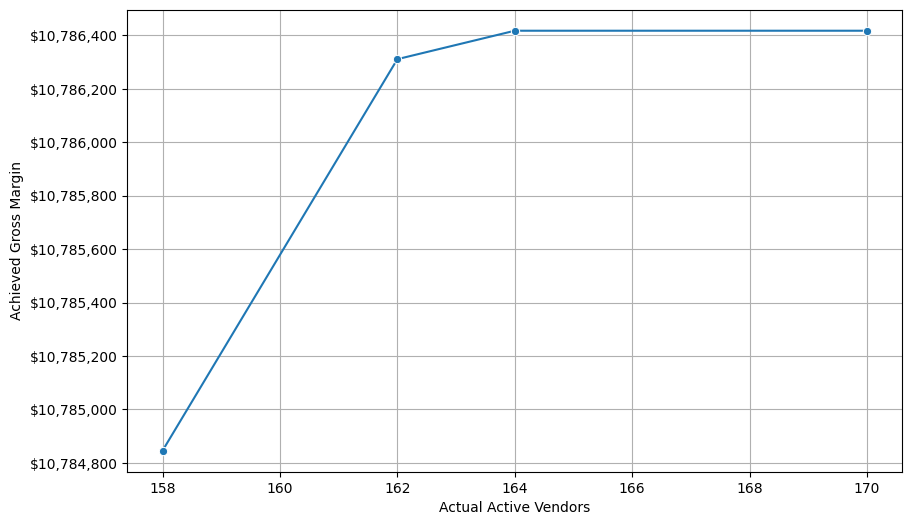

In [33]:
# graph Actual_Active_Suppliers vs Achieved_Gross_Margin
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.lineplot(data=results, x='Actual_Active_Suppliers', y='Achieved_Gross_Margin_Dollars', marker='o')
plt.xlabel('Actual Active Vendors')
plt.ylabel('Achieved Gross Margin')
plt.gca().yaxis.set_major_formatter('${x:,.0f}')
plt.grid()
plt.show()


#### Run best optimization and update df

In [38]:
max_suppliers_limit = 162
# max_gross_margin or min_active_suppliers
solution_status, active_suppliers_dict, num_active_suppliers_count, volume_redistribution_dict,achieved_gm_dollars, prob = of.solve_supplier_optimization_zero(SKUS_pulp, SUPPLIERS_pulp, v, A, S, 2, sl, cl, objective_type='maximize_gm_dollars', max_suppliers_limit = max_suppliers_limit, must_keep_sku_ids = must_keep_indices,entity_list= el)

--- Initializing Optimization Problem ---
SKUs (count: 3031): ['0', '1', '2']...
Suppliers (count: 170): ['0', '1', '2']...
Max volume factor (beta): 2
Big M for constraints: 80088415.0
Objective function set to maximize_gm_dollars.
Adding Volume Redistribution Limit constraints...
    Note: SKU 576 has ~0 original volume. Max redistributed volume capped at 528.64.
Adding Supplier Activation constraints (per-SKU linking)...
Adding SKU Give-or-Receive constraints...
Adding Entity constraint...

--- Solving the Optimization Problem ---

--- Optimization Results ---
Status: Optimal
Total number of active suppliers: 162


In [39]:
updated_df = of.update_dataframe_with_new_volume(
        im_final,
        V_solution_values=volume_redistribution_dict,
        skus_order=skus_order,
        item_to_idx_map=item_to_idx_map,
)

In [40]:
print("Current Number of SKUs:", len(updated_df['Entity--Item'].unique()))
print("New Number of SKUs:", len(updated_df[updated_df['suggest_volume'] > 0.1]['Entity--Item'].unique()))
print("\n")
print("Current Yearly Volume:", updated_df['L3M_adj_vol'].sum()*4)
print("New Yearly Volume:", updated_df['suggest_volume'].sum()*4)
print("\n")
print("Current Vendors:", len(updated_df['vgn_name'].unique()))
print("New Vendors:", len(updated_df[updated_df['suggest_volume'] > 0.1]['vgn_name'].unique()))
print("\n")

current_GM = (updated_df['L3M_Sales'].sum() - updated_df['L3M_Cogs'].sum())*4
updated_df['GM/Unit'] = (updated_df['L3M_Sales'] - updated_df['L3M_Cogs']) / updated_df['L3M_adj_vol']
new_GM = (updated_df['GM/Unit'] * updated_df['suggest_volume']).sum()*4

updated_df['Volume_Change'] = updated_df['suggest_volume'] - updated_df['L3M_adj_vol']
updated_df['GM_Change'] = updated_df['Volume_Change'] * updated_df['GM/Unit']

print(f"Current Yearly Total GM: ${current_GM:,.2f}")
print(f"New Yearly Total GM: ${new_GM:,.2f}")
print(f"GM Difference: ${(updated_df['Volume_Change'] * updated_df['GM/Unit']).sum() * 4:,.2f}")

Current Number of SKUs: 3031
New Number of SKUs: 2867


Current Yearly Volume: 3203536.6
New Yearly Volume: 3203536.6


Current Vendors: 170
New Vendors: 162


Current Yearly Total GM: $42,919,054.56
New Yearly Total GM: $43,145,245.33
GM Difference: $226,250.53


In [ ]:
im_final_with_feedback = pd.read_csv(f"{OP_PATH}{CATEGORY}_feedback_df_{today}.csv")

In [ ]:
#im_final_with_feedback2 = pd.DataFrame(columns = im_final_with_feedback.columns)

In [59]:
frf.create_enhanced_sku_report(updated_df, f"{OP_PATH}{CATEGORY}_Final_Report_{today}.xlsx", volume_redistribution_dict, item_to_idx_map, im_final_with_feedback2, true_l3m_grouped.to_pandas(), customer_exclusions = customer_exclusions, redi_customers = redi['customer'].unique().to_list())

--- Starting to generate Enhanced SKU Report: C:\Users\ZWayne\OneDrive - Advent International\Advent Labs - Documents\02. Portfolio Companies\Imperial Dade\Category Mgmt Project\Data\Output\Soap & Sanitizer_Final_Report_08.15.2025.xlsx ---

--- Processing Sheet: Suggested Swaps ---

--- Processing Sheet: Drop List ---

--- Processing Sheet: Vendor Performance Summary ---

--- Processing Sheet: Customer Performance Summary ---

Successfully created Excel report: C:\Users\ZWayne\OneDrive - Advent International\Advent Labs - Documents\02. Portfolio Companies\Imperial Dade\Category Mgmt Project\Data\Output\Soap & Sanitizer_Final_Report_08.15.2025.xlsx


True

In [49]:
#im_final.to_excel(f"{OP_PATH}{CATEGORY}_Full_{today}.xlsx", index=False)

# Optimization Feedback

In [60]:
# drop_list_df, suggested_swaps_df = f.read_and_process_feedback_excel( f"{OP_PATH}{CATEGORY}_drop_list_{today}.xlsx")
drop_list_df, suggested_swaps_df = frf.read_and_process_feedback_excel( f"{OP_PATH}Soap & Sanitizer_Final_Report_08.15.2025.xlsx", suggest_swaps_sheet_name='All Suggested Swaps', suggest_swaps_orig_sku_col='Originating SKU ID', suggest_swaps_recv_sku_col='Receiving SKU ID')

--- Reading feedback from Excel file: C:\Users\ZWayne\OneDrive - Advent International\Advent Labs - Documents\02. Portfolio Companies\Imperial Dade\Category Mgmt Project\Data\Output\Soap & Sanitizer_Final_Report_08.15.2025.xlsx ---
Processing sheet: Drop List...
Successfully extracted data from 'Drop List'. Found 186 rows.


In [61]:
im_final = frf.incorporate_swaps_feedback(im_final, suggested_swaps_df)

## Go back and rerun optimization

In [ ]:
of.create_enhanced_sku_report_post_feedback(updated_df, f"{OP_PATH}{CATEGORY}_drop_list_{today}_cust.xlsx", volume_redistribution_dict, item_to_idx_map,im_final_with_feedback, true_l3m_grouped, suggested_swaps_df,openai_response_col = 'openai_response')